# Classification Audio — PySpark + MLlib
**Projet Spark Core - M1 T2 2026**

Pipeline complet :
1. Imports et session Spark
2. Chargement Parquet -> DataFrame + RDD
3. Distribution des classes (RDD clé/valeur)
4. Aplatissement des colonnes array -> colonnes scalaires (`df_flat`)
5. Corrélation features -> label (sélection des features utiles)
6. Split Train / Test (Spark DataFrames)
7. Calcul des poids par classe (rééquilibrage sur le train)
8. Pipeline MLlib : `StringIndexer` -> `VectorAssembler` -> `StandardScaler`
9. RandomForest Spark (pipeline complet + évaluation, matrice de confusion, sauvegarde du modèle)
10. XGBoost
    - Entrainement `XGBClassifier`
    - Évaluation (accuracy, rapport par classe, matrice de confusion)

## 1. Imports et session Spark

In [2]:
import os
import sys

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql.functions import col, lit
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("PySpark version :", pyspark.__version__)

PySpark version : 3.5.1


In [3]:
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (SparkSession.builder
    .master("local[*]")                         
    .config("spark.driver.memory",   "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8") 
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")         
print("Spark démarré :", spark.version)

Spark démarré : 3.5.8


## 2. Chargement des données

In [4]:
df = spark.read.parquet(r"C:\Users\khaou\Documents\p_spark\audio_features.parquet")

df.printSchema()
df.show(3, truncate=True)
print("Nombre de lignes  :", df.count())
print("Nombre de colonnes:", len(df.columns))

rdd = df.rdd

root
 |-- path: string (nullable = true)
 |-- duration: float (nullable = true)
 |-- num_samples: integer (nullable = true)
 |-- mfccs_mean: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- mfccs_std: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- spectral_centroid_mean: float (nullable = true)
 |-- spectral_centroid_std: float (nullable = true)
 |-- spectral_rolloff_mean: float (nullable = true)
 |-- spectral_rolloff_std: float (nullable = true)
 |-- zcr_mean: float (nullable = true)
 |-- zcr_std: float (nullable = true)
 |-- chroma_mean: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- chroma_std: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- mel_spec_mean: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- mel_spec_std: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- rms_mean: float (nullable = true)
 |-- rms_std: float

## 3. Distribution des classes — RDD clé/valeur

In [5]:
counts_rdd = (
    rdd
    .map(lambda row: (row["label"], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda x: x[0])
)

print("Distribution par classe :")
for classe, count in counts_rdd.collect():
    print(f"  {classe:<25} : {count} fichiers")

# toDebugString() : affiche le plan d'exécution (DAG lazy) 
print("\n── DAG RDD (toDebugString) ──")
print(counts_rdd.toDebugString().decode("utf-8"))

Distribution par classe :
  air_conditioner           : 1000 fichiers
  car_horn                  : 429 fichiers
  children_playing          : 1000 fichiers
  dog_bark                  : 1000 fichiers
  drilling                  : 1000 fichiers
  engine_idling             : 1000 fichiers
  gun_shot                  : 374 fichiers
  jackhammer                : 1000 fichiers
  siren                     : 929 fichiers
  street_music              : 1000 fichiers

── DAG RDD (toDebugString) ──
(4) PythonRDD[29] at collect at C:\Users\khaou\AppData\Local\Temp\ipykernel_15072\549232266.py:9 []
 |  MapPartitionsRDD[28] at mapPartitions at PythonRDD.scala:160 []
 |  ShuffledRDD[27] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(4) PairwiseRDD[26] at sortBy at C:\Users\khaou\AppData\Local\Temp\ipykernel_15072\549232266.py:5 []
    |  PythonRDD[25] at sortBy at C:\Users\khaou\AppData\Local\Temp\ipykernel_15072\549232266.py:5 []
    |  MapPartitionsRDD[22] at mapPartitions at PythonRDD.s

## 4. Aplatissement des colonnes array → colonnes scalaires (`df_flat`)

In [6]:
# Le DataFrame df contient des colonnes de type Array (mfccs_mean, mel_spec_mean…)
# MLlib a besoin de colonnes scalaires individuelles
# On aplatit chaque tableau : mfccs_mean[0] -> mfcc_0, mfccs_mean[1] → mfcc_1, .....

scalar_features = [
    "spectral_centroid_mean", "spectral_centroid_std",
    "spectral_rolloff_mean",  "spectral_rolloff_std",
    "zcr_mean",  "zcr_std",
    "rms_mean",  "rms_std",
]

array_cols = {
    "mfccs_mean":    13,
    "mfccs_std":     13,
    "mel_spec_mean": 128,
    "mel_spec_std":  128,
    "chroma_mean":   12,
    "chroma_std":    12,
}

exprs = scalar_features + ["label"]  # on garde les scalaires + le label

for col_name, size in array_cols.items():
    for i in range(size):
        # col("mfccs_mean")[0].alias("mfccs_mean_0"),....
        exprs.append(col(col_name)[i].alias(f"{col_name}_{i}"))

df_flat = df.select(*exprs)

print("Schéma de df_flat :")
df_flat.printSchema()
print(f"\nNombre de colonnes dans df_flat : {len(df_flat.columns)}")
df_flat.show(3, truncate=True)

Schéma de df_flat :
root
 |-- spectral_centroid_mean: float (nullable = true)
 |-- spectral_centroid_std: float (nullable = true)
 |-- spectral_rolloff_mean: float (nullable = true)
 |-- spectral_rolloff_std: float (nullable = true)
 |-- zcr_mean: float (nullable = true)
 |-- zcr_std: float (nullable = true)
 |-- rms_mean: float (nullable = true)
 |-- rms_std: float (nullable = true)
 |-- label: string (nullable = true)
 |-- mfccs_mean_0: float (nullable = true)
 |-- mfccs_mean_1: float (nullable = true)
 |-- mfccs_mean_2: float (nullable = true)
 |-- mfccs_mean_3: float (nullable = true)
 |-- mfccs_mean_4: float (nullable = true)
 |-- mfccs_mean_5: float (nullable = true)
 |-- mfccs_mean_6: float (nullable = true)
 |-- mfccs_mean_7: float (nullable = true)
 |-- mfccs_mean_8: float (nullable = true)
 |-- mfccs_mean_9: float (nullable = true)
 |-- mfccs_mean_10: float (nullable = true)
 |-- mfccs_mean_11: float (nullable = true)
 |-- mfccs_mean_12: float (nullable = true)
 |-- mfccs_std

## 5. Corrélation features ↔ label

In [7]:
# On encode d'abord le label en nombre entier
# StringIndexer : "label1" -> 0, "label2" -> 1
indexer    = StringIndexer(inputCol="label", outputCol="label_encoded")
df_encoded = indexer.fit(df_flat).transform(df_flat)
feature_cols = [c for c in df_flat.columns if c != "label"]
print(f"Nombre de features : {len(feature_cols)}")

#calcul de la corrélation de pearson (|r|) de chaque feature avec le label
# df.stat.corr(col1, col2) renvoie un float entre -1 et 1
corr_label = {}
for feature in feature_cols:
    r = df_encoded.stat.corr(feature, "label_encoded")
    corr_label[feature] = abs(r)         

corr_series = pd.Series(corr_label).sort_values(ascending=False)

print("\nTop 10 features les plus corrélées avec le label :")
print(corr_series.head(10).to_string())
print("\nBottom 10 features les moins corrélées :")
print(corr_series.tail(10).to_string())

Nombre de features : 314

Top 10 features les plus corrélées avec le label :
mfccs_mean_8        0.217213
mel_spec_mean_46    0.202756
chroma_mean_10      0.187507
mel_spec_mean_47    0.175009
mel_spec_mean_52    0.170503
mel_spec_mean_53    0.167125
mel_spec_mean_51    0.167092
mfccs_mean_12       0.166905
mel_spec_mean_43    0.166318
mel_spec_mean_50    0.165534

Bottom 10 features les moins corrélées :
mel_spec_mean_104    0.001887
mel_spec_std_22      0.001523
mel_spec_std_64      0.001330
mel_spec_std_105     0.001304
mel_spec_std_98      0.001174
mel_spec_mean_58     0.001037
mel_spec_std_116     0.000601
mel_spec_std_61      0.000175
mel_spec_std_93      0.000121
mel_spec_mean_22     0.000018


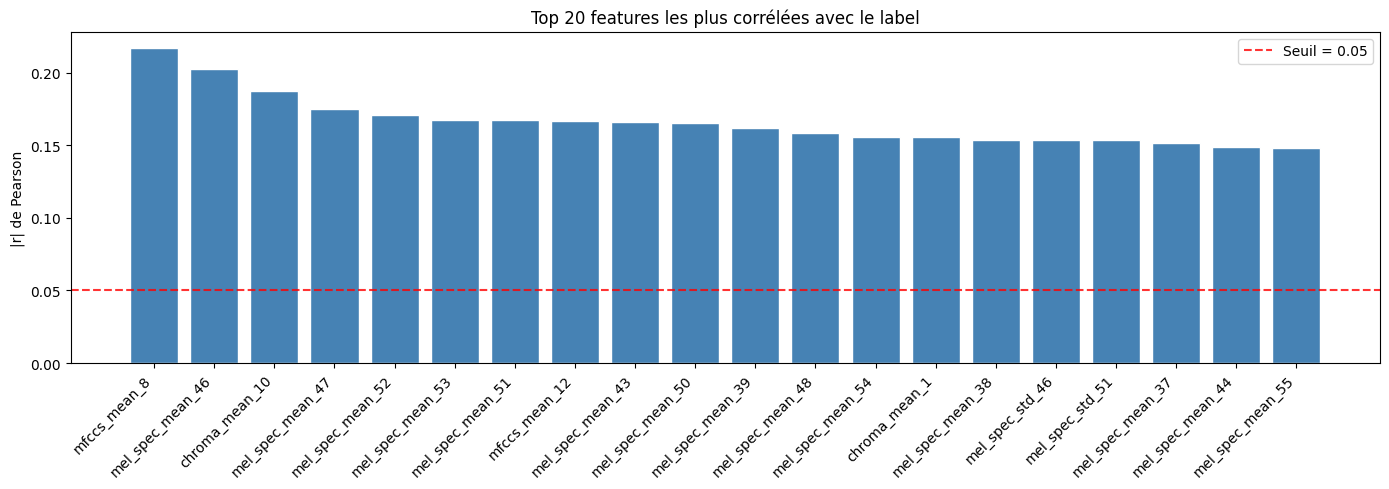

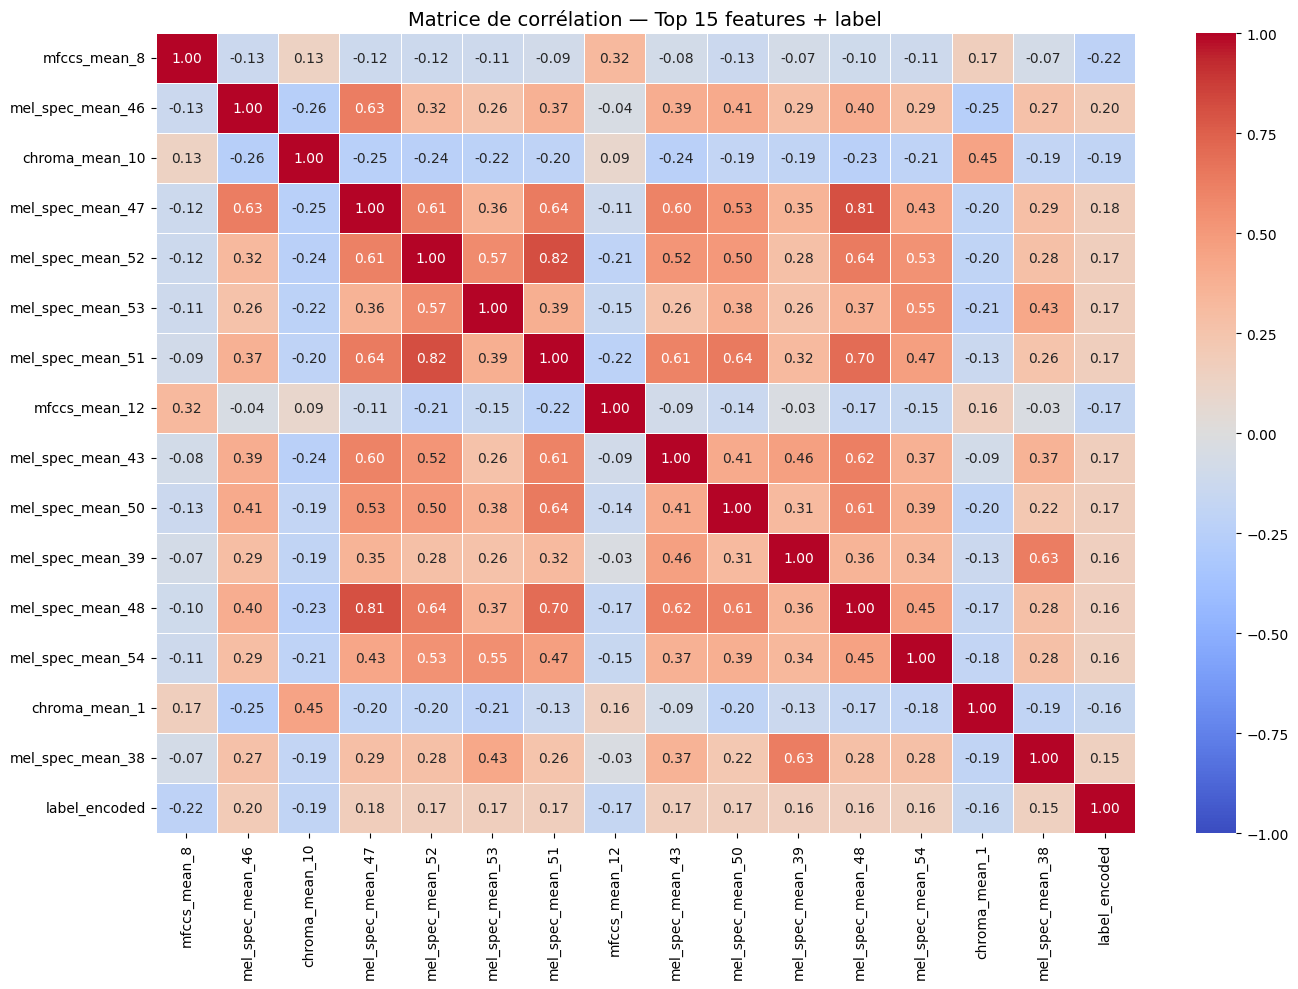

Features retenues (|r| ≥ 0.05) : 141 / 314


In [8]:
#Barplot Top 20 
seuil_label = 0.05   # seuil de corrélation minimale
top20 = corr_series.head(20)

plt.figure(figsize=(14, 5))
couleurs = ["steelblue" if v >= seuil_label else "tomato" for v in top20.values]
plt.bar(top20.index, top20.values, color=couleurs, edgecolor="white")
plt.axhline(seuil_label, color="red", linestyle="--", alpha=0.8,label=f"Seuil = {seuil_label}")
plt.title("Top 20 features les plus corrélées avec le label", fontsize=12)
plt.ylabel("|r| de Pearson")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

top_features = corr_series.head(15).index.tolist()

df_top =  df_encoded.select(top_features + [ "label_encoded"]).toPandas()
corr_matrix = df_top.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice de corrélation — Top 15 features + label", fontsize=14)
plt.tight_layout()
plt.show()

features_utiles = [feat for feat, r in corr_label.items() if r >= seuil_label]
print(f"Features retenues (|r| ≥ {seuil_label}) : " f"{len(features_utiles)} / {len(feature_cols)}")

## 6. Corrélation features -> features (suppression des doublons)

In [9]:
# Objectif : détecter les paires de features très corrélées entre elles (|r| > 0.90)
# Si deux features disent la même chose on peut en supprimer une

# assembler toutes les features dans un seul vecteur Spark 
# Correlation de MLlib attend une colonne de type Vector
assembler_corr = VectorAssembler(
    inputCols=features_utiles,
    outputCol="features_corr",
    handleInvalid="keep"
)
df_vect = assembler_corr.transform(df_encoded)

# calcul de la matrice avec Spark MLlib Correlation 
# Correlation.corr() effectue le calcul distribué 
# method="pearson" : corrélation linéaire

corr_spark = Correlation.corr(df_vect, "features_corr", method="pearson")

matrix_spark = corr_spark.collect()[0]["pearson(features_corr)"]

print("Type retourné par Spark :", type(matrix_spark))
print(f"Taille de la matrice    : {matrix_spark.numRows} × {matrix_spark.numCols}")

corr_array = matrix_spark.toArray()   # numpy ndarray (n_features × n_features)

corr_matrix_ff = pd.DataFrame(corr_array, index=features_utiles, columns=features_utiles)


Type retourné par Spark : <class 'pyspark.ml.linalg.DenseMatrix'>
Taille de la matrice    : 141 × 141


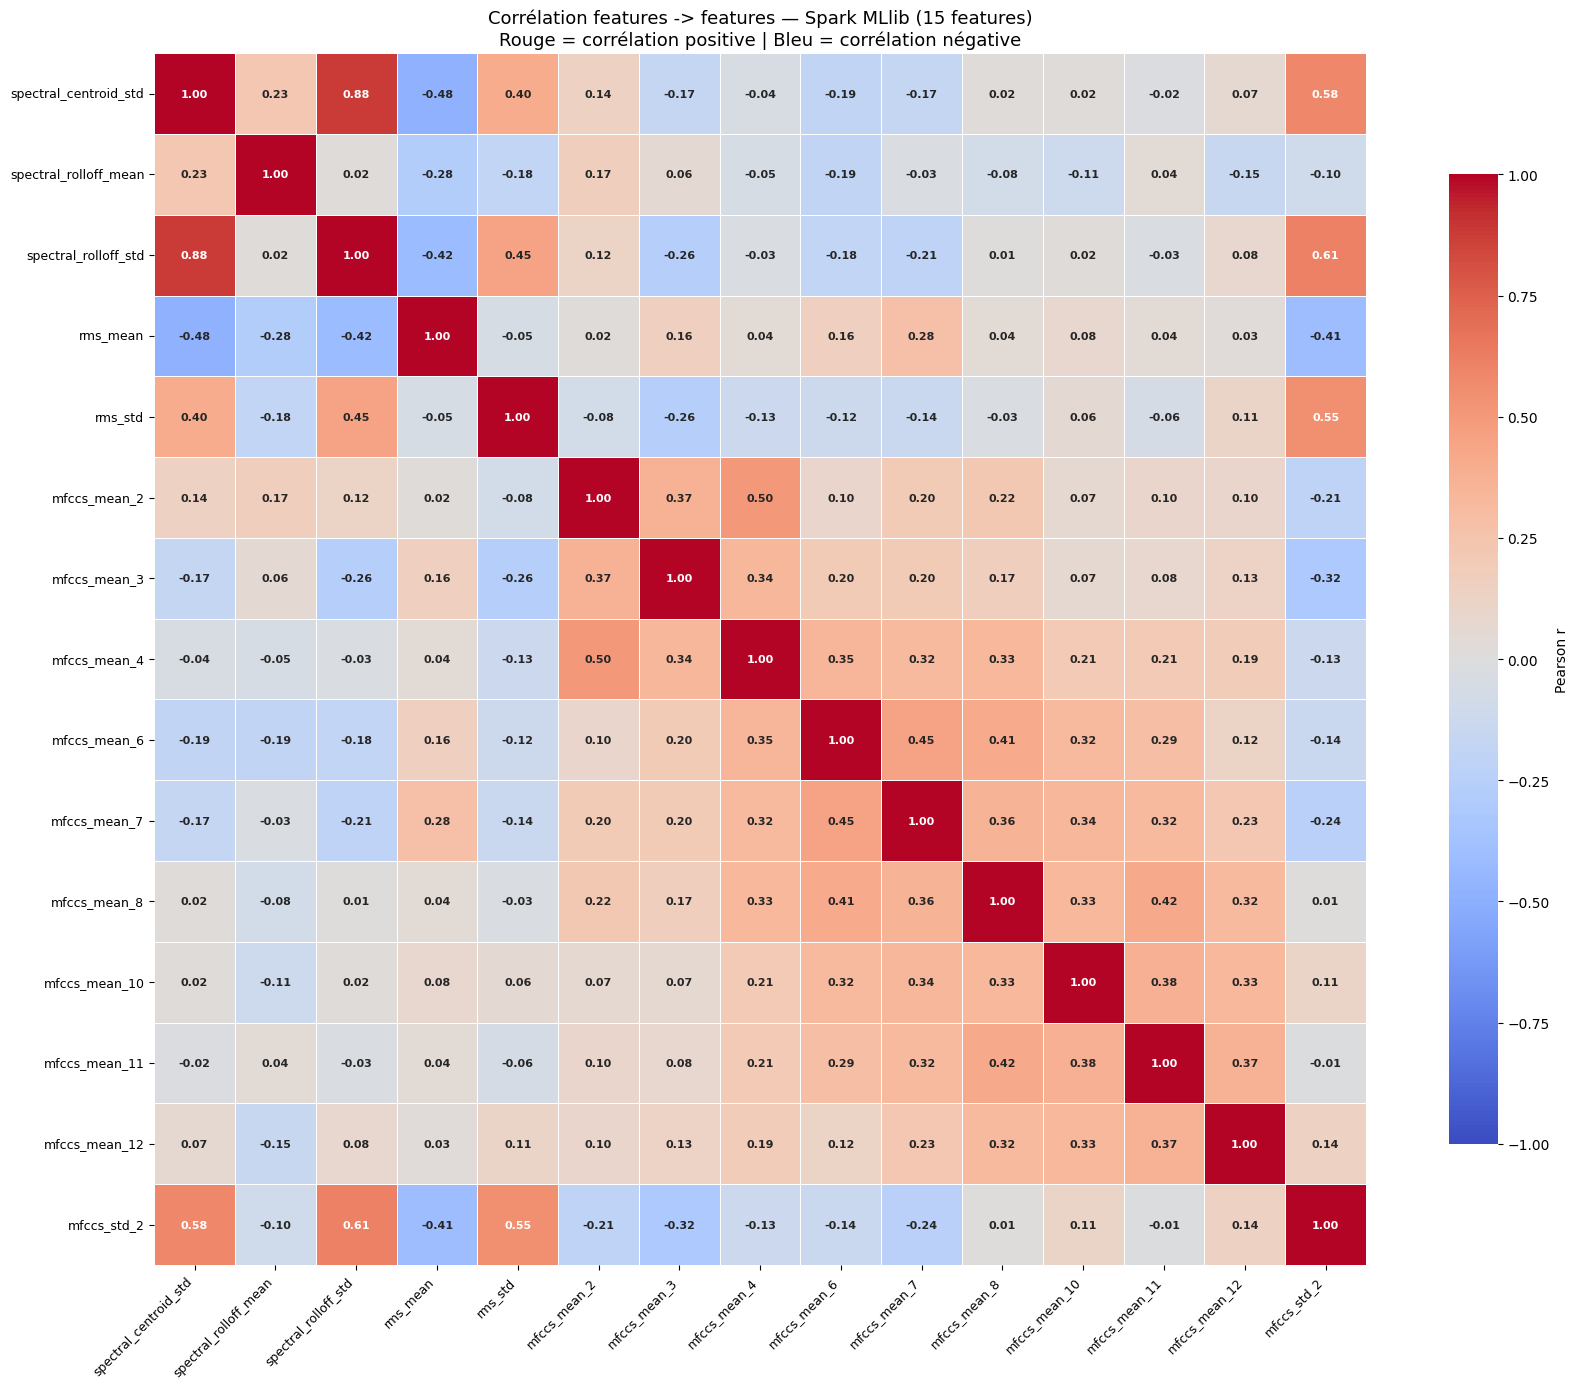

Paires de features avec |r| > 0.85 : 27 paire(s)

  mel_spec_mean_100                    ->  mel_spec_std_100                     |r| = 0.969
  mel_spec_mean_79                     ->  mel_spec_std_79                      |r| = 0.967
  mel_spec_mean_106                    ->  mel_spec_mean_107                    |r| = 0.939
  mel_spec_mean_77                     ->  mel_spec_std_77                      |r| = 0.938
  mel_spec_mean_55                     ->  mel_spec_std_55                      |r| = 0.912
  mel_spec_mean_26                     ->  mel_spec_std_26                      |r| = 0.901
  mfccs_std_11                         ->  mfccs_std_12                         |r| = 0.897
  mel_spec_std_51                      ->  mel_spec_std_52                      |r| = 0.893
  mel_spec_mean_80                     ->  mel_spec_std_80                      |r| = 0.892
  mel_spec_mean_52                     ->  mel_spec_std_52                      |r| = 0.891
  mfccs_std_10                

In [10]:
n_affiche = min(15, len(features_utiles))
sous_matrice = corr_matrix_ff.iloc[:n_affiche, :n_affiche]

sous_matrice_arrondie = sous_matrice.round(2)

plt.figure(figsize=(18, 14))
sns.heatmap(
    sous_matrice_arrondie,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot_kws={"size": 8, "weight": "bold"}, 
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
plt.title(
    f"Corrélation features -> features — Spark MLlib ({n_affiche} features)\n"
    f"Rouge = corrélation positive | Bleu = corrélation négative",
    fontsize=13
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

seuil_f = 0.85

n = len(features_utiles)
triplets = [
    (features_utiles[i], features_utiles[j], float(abs(corr_array[i, j])))
    for i in range(n)
    for j in range(i + 1, n)   
]

cor_rdd   = spark.sparkContext.parallelize(triplets)
paires_rdd= (
    cor_rdd
    .filter(lambda x: x[2] > seuil_f)
    .sortBy(lambda x: -x[2]) 
)
paires_correlees = paires_rdd.collect() 

print(f"Paires de features avec |r| > {seuil_f} : {len(paires_correlees)} paire(s)\n")

for feat_i, feat_j, r in paires_correlees[:20]:
    print(f"  {feat_i:<35}  ->  {feat_j:<35}  |r| = {r:.3f}")


In [11]:
a_supprimer_rdd = (
    paires_rdd
    .map(lambda x: x[1])       # on prend feat_j de chaque paire (feat_i, feat_j, r)
    .distinct()
)
a_supprimer = set(a_supprimer_rdd.collect())
features_finales = [feat for feat in features_utiles if feat not in a_supprimer]

print(f"\nFeatures avant suppression  : {len(features_utiles)}")
print(f"Features supprimées          : {len(a_supprimer)}")
print(f"Features finales retenues    : {len(features_finales)}")
print(f"\nFeatures supprimées :")
for feat in sorted(a_supprimer):
    print(f"  - {feat}")


Features avant suppression  : 141
Features supprimées          : 22
Features finales retenues    : 119

Features supprimées :
  - mel_spec_mean_107
  - mel_spec_std_1
  - mel_spec_std_10
  - mel_spec_std_100
  - mel_spec_std_26
  - mel_spec_std_33
  - mel_spec_std_40
  - mel_spec_std_41
  - mel_spec_std_47
  - mel_spec_std_48
  - mel_spec_std_50
  - mel_spec_std_52
  - mel_spec_std_55
  - mel_spec_std_77
  - mel_spec_std_78
  - mel_spec_std_79
  - mel_spec_std_80
  - mfccs_std_10
  - mfccs_std_11
  - mfccs_std_12
  - mfccs_std_8
  - spectral_rolloff_std


## 6. Split Train / Test

In [12]:
# randomSplit : divise le DataFrame Spark en deux souss ensembles aléatoires

train_df_raw, test_df_raw = df_flat.randomSplit([0.8, 0.2], seed=42)

print(f"Lignes d'entraînement : {train_df_raw.count()}")
print(f"Lignes de test        : {test_df_raw.count()}")

Lignes d'entraînement : 7064
Lignes de test        : 1668


## 7. Poids par classe (rééquilibrage)

In [13]:
# Formule : weight = total / (nb_classes × n_classe)
#les classes rares auront un poids plus élevé
# On utilise groupBy + withColumn + join 

total      = train_df_raw.count()
nb_classes = train_df_raw.select("label").distinct().count()

poids_df = (
    train_df_raw
    .groupBy("label")
    .agg(f.count("*").alias("n_classe"))
    .withColumn("weight", lit(total) / (lit(nb_classes) * col("n_classe")))
    .select("label", "weight")
)

print("Poids calculés par classe :")
poids_df.orderBy("label").show()

train_df = train_df_raw.join(poids_df, on="label", how="left")
test_df  = test_df_raw   

print(f"Colonnes de train_df : {train_df.columns}")

Poids calculés par classe :
+----------------+------------------+
|           label|            weight|
+----------------+------------------+
| air_conditioner|0.8667484662576687|
|        car_horn| 2.127710843373494|
|children_playing|0.9010204081632653|
|        dog_bark|0.8764267990074441|
|        drilling|0.8646266829865361|
|   engine_idling|0.8604141291108405|
|        gun_shot|2.4109215017064844|
|      jackhammer|0.8874371859296483|
|           siren|0.9079691516709512|
|    street_music| 0.859367396593674|
+----------------+------------------+

Colonnes de train_df : ['label', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'zcr_mean', 'zcr_std', 'rms_mean', 'rms_std', 'mfccs_mean_0', 'mfccs_mean_1', 'mfccs_mean_2', 'mfccs_mean_3', 'mfccs_mean_4', 'mfccs_mean_5', 'mfccs_mean_6', 'mfccs_mean_7', 'mfccs_mean_8', 'mfccs_mean_9', 'mfccs_mean_10', 'mfccs_mean_11', 'mfccs_mean_12', 'mfccs_std_0', 'mfccs_std_1', 'mfccs_std_2', 'mfc

## 8. Pipeline MLlib

In [14]:
all_features = features_finales

# Convertit le label texte 
label_indexer = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="keep"  
)

# Rassemble toutes les colonnes de features en un seul vecteur
assembler = VectorAssembler(
    inputCols=all_features,
    outputCol="features",
    handleInvalid="keep"
)

# Normalise chaque feature : soustrait la moyenne, divise par l'écart-type
scaler = StandardScaler(
    inputCol="features",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

rf = RandomForestClassifier(
    labelCol="label_index",
    featuresCol="features_scaled",  # on utilise les features normalisées
    weightCol="weight",             # poids pour rééquilibrer les classes
    numTrees=200,
    maxDepth=10,
    minInstancesPerNode=3,
    featureSubsetStrategy="sqrt",   # à chaque split : sqrt(nb_features) features testées
    seed=42
)

pipeline = Pipeline(stages=[label_indexer, assembler, scaler, rf])
print("Pipeline créé : StringIndexer → VectorAssembler → StandardScaler → RandomForest")

Pipeline créé : StringIndexer → VectorAssembler → StandardScaler → RandomForest


## 9. Random Forest

In [15]:
print("Entrainement en cours… ")
model = pipeline.fit(train_df)
print("Entrainement terminé !")

Entrainement en cours… 
Entrainement terminé !


### Évaluation

In [16]:
# model.transform(test_df) applique le pipeline sur le jeu de test
predictions = model.transform(test_df)

# MulticlassClassificationEvaluator : calcule accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy sur le test : {accuracy * 100:.2f}%")


Accuracy sur le test : 84.47%


### Matrice de confusion

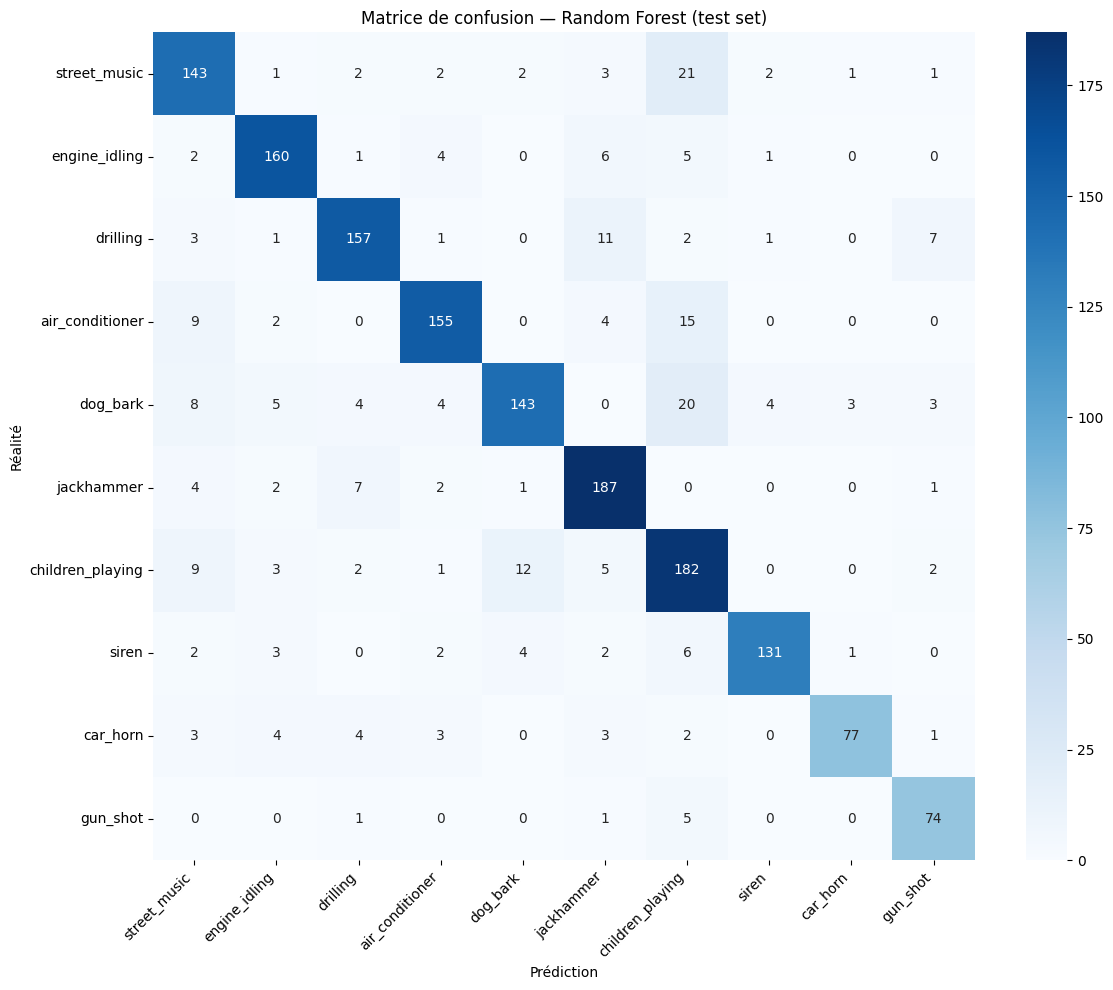

In [17]:
# On extrait uniquement les colonnes utiles pour la matrice
rows = predictions.select("label_index", "prediction").dropna().collect()

y_true = [int(r["label_index"]) for r in rows]
y_pred = [int(r["prediction"])  for r in rows]

class_labels = model.stages[0].labels

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion — Random Forest (test set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. XGBoost

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [19]:
prep_pipeline = Pipeline(stages=[label_indexer, assembler, scaler])
prep_model = prep_pipeline.fit(train_df)

train_prepared = prep_model.transform(train_df)
test_prepared  = prep_model.transform(test_df)

train_pd = train_prepared.select("features_scaled", "label_index").toPandas()
test_pd  = test_prepared.select("features_scaled", "label_index").toPandas()

X_train = np.vstack(train_pd["features_scaled"].values)
y_train = train_pd["label_index"].values

X_test = np.vstack(test_pd["features_scaled"].values)
y_test = test_pd["label_index"].values

### Entrainement 

In [20]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    verbosity=1
)

print(" Entrainement XGBoost en cours...")
xgb_model.fit(X_train, y_train)
print(" XGBoost entrainé !")


 Entrainement XGBoost en cours...
 XGBoost entrainé !


### Évaluation

In [21]:
y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("XGBoost — Accuracy : ")
print(f"{acc * 100:.2f}%\n")

print("Rapport par classe :")
print(classification_report(y_test, y_pred))

XGBoost — Accuracy : 
91.73%

Rapport par classe :
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86       178
         1.0       0.95      0.96      0.95       179
         2.0       0.90      0.96      0.93       183
         3.0       0.97      0.92      0.94       185
         4.0       0.93      0.90      0.91       194
         5.0       0.93      0.93      0.93       204
         6.0       0.83      0.91      0.87       216
         7.0       0.98      0.93      0.96       151
         8.0       0.98      0.84      0.90        97
         9.0       0.99      0.91      0.95        81

    accuracy                           0.92      1668
   macro avg       0.93      0.91      0.92      1668
weighted avg       0.92      0.92      0.92      1668



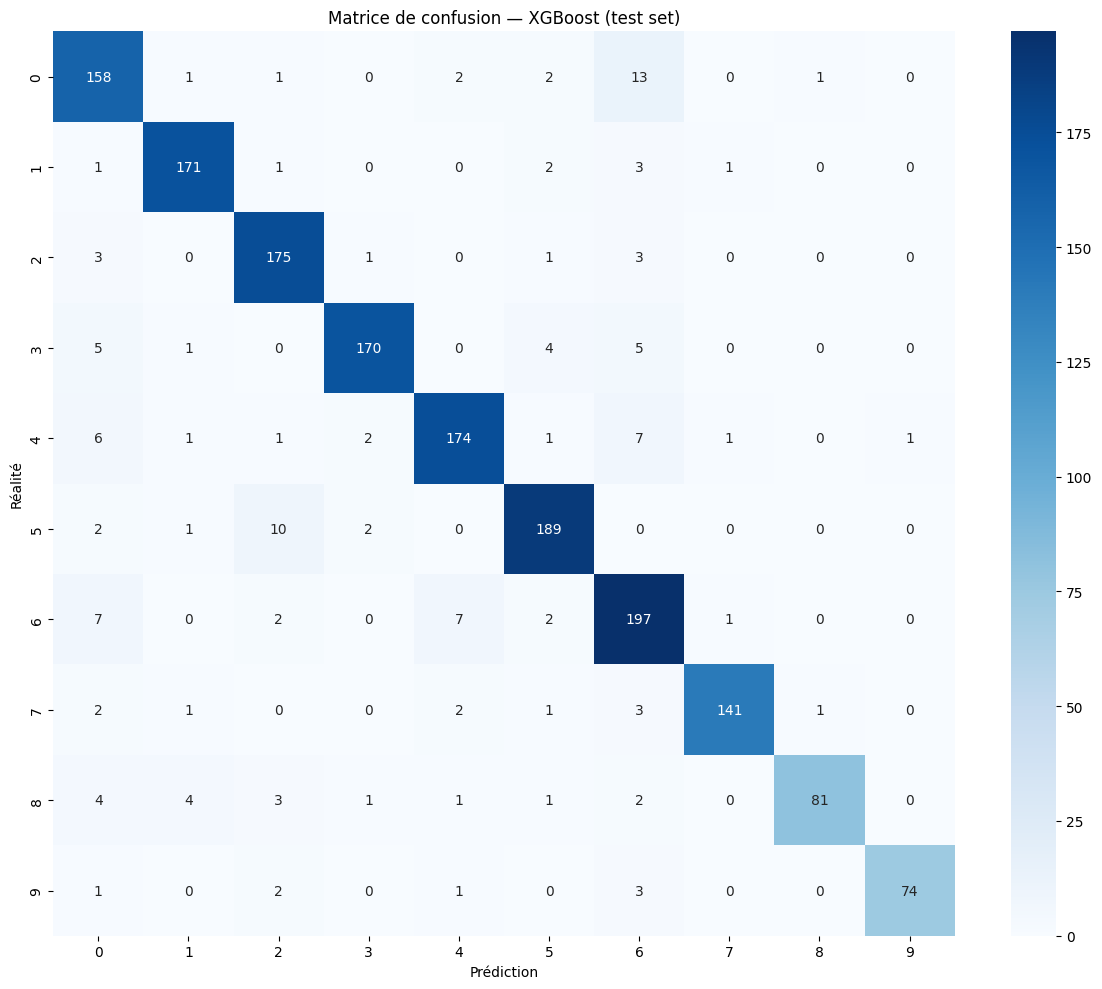

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot  =True, fmt="d", cmap="Blues")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion — XGBoost")
plt.tight_layout()
plt.show()

## 11. Extraction des modèles

In [24]:
import joblib

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_PATH_RF = os.path.join(MODELS_DIR, "rf_model")
model.write().overwrite().save(MODEL_PATH_RF)
print(f"Modèle RandomForest Spark sauvegardé dans : {MODEL_PATH_RF}")

MODEL_PATH_XGB = os.path.join(MODELS_DIR, "xgb_model.joblib")
joblib.dump(xgb_model, MODEL_PATH_XGB)
print(f"Modèle XGBoost sauvegardé dans : {MODEL_PATH_XGB}")


Modèle RandomForest Spark sauvegardé dans : models\rf_model
Modèle XGBoost sauvegardé dans : models\xgb_model.joblib
